# Applying Functions to Series
# pandas.Series.apply
#### pandas.Series.apply() method is used to invoke a function element-wise on every value of a pandas Series. It is most commonly used to transform, clean, or categorize data based on custom conditions

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [34]:
titanic = pd.read_csv('../../../data/titanic.csv')

In [35]:
titanic['age'] = titanic['age'].replace(['?'], [None]).astype('float')
titanic['fare'] = titanic['fare'].replace(['?'], [None]).astype('float')

In [36]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,?,C,?,328,?
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,?,C,?,?,?
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,?,C,?,304,?
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,?,C,?,?,?


## We will create a simple function that converts years into days

In [37]:
def year_to_days(yrs):
    return yrs * 365

## Now we will use this function inside .apply()

In [38]:
titanic['age'].apply(year_to_days)

0       10585.0000
1         334.5955
2         730.0000
3       10950.0000
4        9125.0000
           ...    
1304     5292.5000
1305           NaN
1306     9672.5000
1307     9855.0000
1308    10585.0000
Name: age, Length: 1309, dtype: float64

## Now we will create a function that can get us the age group

In [39]:
def get_age_group(age):
    if age < 2:
        return 'infant'
    elif age < 12:
        return 'child'
    elif age < 18:
        return 'teen'
    elif age < 50:
        return 'adult'
    else:
        return 'senior'

In [40]:
titanic['age'].apply(get_age_group)

0        adult
1       infant
2        child
3        adult
4        adult
         ...  
1304      teen
1305    senior
1306     adult
1307     adult
1308     adult
Name: age, Length: 1309, dtype: object

In [41]:
titanic['age_group'] = titanic['age'].apply(get_age_group)

In [42]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,age_group
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO",adult
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON",infant
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON",child
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON",adult
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON",adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,?,C,?,328,?,teen
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,?,C,?,?,?,senior
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,?,C,?,304,?,adult
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,?,C,?,?,?,adult


<Axes: xlabel='age_group'>

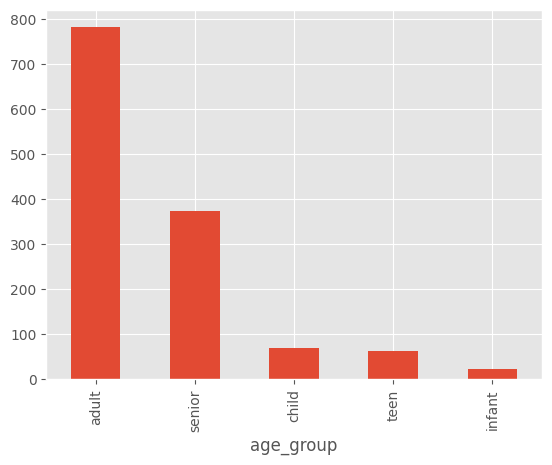

In [43]:
titanic['age_group'].value_counts().plot(kind='bar')

## Find out the average survived by age_group

<Axes: xlabel='age_group'>

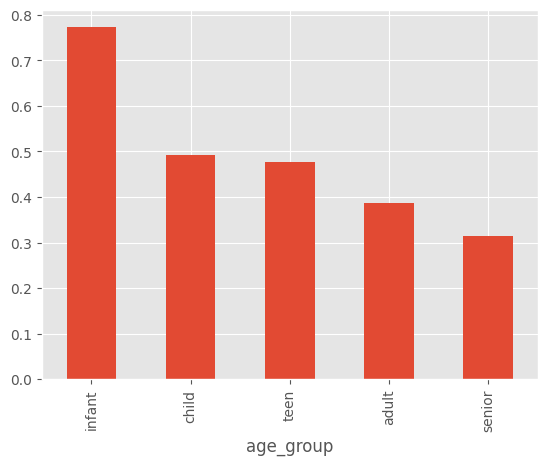

In [51]:
titanic.groupby('age_group')['survived'].mean().sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='sex,age_group'>

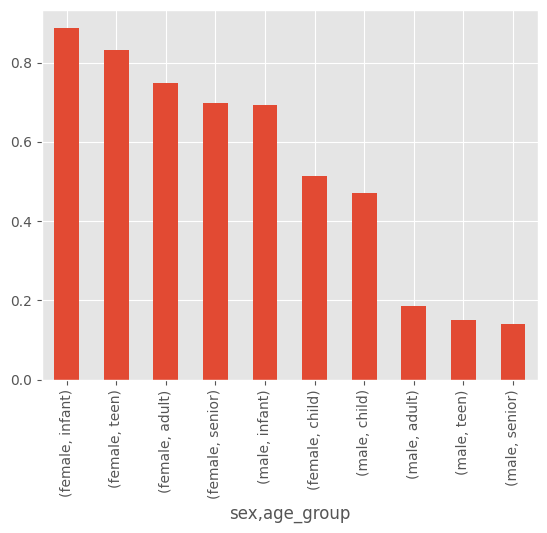

In [54]:
titanic.groupby(['sex','age_group'])['survived'].mean().sort_values(ascending=False).plot(kind='bar')